In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import statsmodels.api as sm


In [102]:
data = pd.read_excel('C:/Users/lenovo/Desktop/Analyse/data.xlsx', engine='openpyxl', sheet_name='Data')
data['Mois'] = pd.to_datetime(data['Mois'], format='%m-%Y')
data = data.set_index('Mois')
data = data.sort_index()
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 320 entries, 2000-01-01 to 2026-08-01
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EUR_DZD            320 non-null    float64
 1   USD_DZD            320 non-null    float64
 2   IPC_DZ             290 non-null    float64
 3   IPC_US             290 non-null    float64
 4   Brent              320 non-null    float64
 5   Taux_directeur_BA  114 non-null    float64
 6   USD_EUR            320 non-null    float64
 7   RSV                97 non-null     float64
dtypes: float64(8)
memory usage: 22.5 KB


In [103]:
sources = pd.read_excel('C:/Users/lenovo/Desktop/Analyse/data.xlsx', engine='openpyxl', sheet_name='Source')
sources['Premier_mois'] = pd.to_datetime(sources['Premier_mois']).dt.strftime("%m-%Y")
sources['Dernier_mois'] = pd.to_datetime(sources['Dernier_mois']).dt.strftime("%m-%Y")
sources

,Code,Indicateur,Source,Premier_mois,Dernier_mois
0,EUR_DZD,Moyenne mensuelle du taux de change EUR/DZD,Banque d'Algérie,01-2000,08-2026
1,USD_DZD,Moyenne mensuelle du taux de change USD/DZD,Banque d'Algérie,01-2000,08-2026
2,IPC_DZ,Indice des prix à la consommation en Algerie,Banque d'Algérie,01-2002,02-2026
3,IPC_US,Indice des prix à la consommation en US,U.S. Bureau of Labor Statistics,01-2002,02-2026
4,Brent,Moyenne Mensuelle du prix Spot du baril brent ...,U.S. Energy Information Administration,01-2000,08-2026
5,Taux_directeur,Taux directeur de la Banque d'Algérie,Banque d'Algérie,03-2017,08-2026
6,USD_EUR,Parité USD/EUR,BCE (Banque Centrale Européenne) (4F0),01-2000,08-2026
7,RSV,Réserves officielles de change y compris DTS (...,Banque d'Algérie,12-2015,12-2023


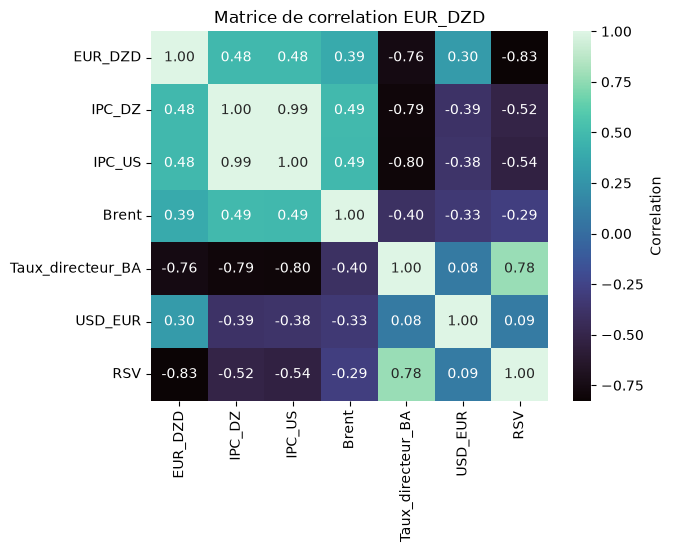

In [106]:
df = data.loc['2017-01':].copy()
correlation_matrix_eur = df.drop(['USD_DZD'], axis=1).corr()
sns.heatmap(correlation_matrix_eur, annot=True, cmap='mako', fmt='.2f', annot_kws={"size": 10}, cbar_kws={"label": "Correlation"})
plt.title('Matrice de correlation EUR_DZD')
plt.show()


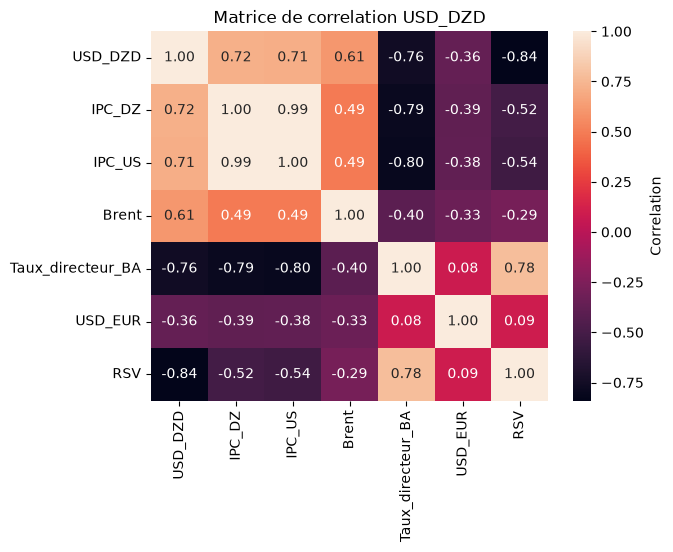

In [107]:
correlation_matrix_usd = df.drop(['EUR_DZD'], axis=1).corr()
sns.heatmap(correlation_matrix_usd, annot=True, cmap='rocket', fmt='.2f', annot_kws={"size": 10}, cbar_kws={"label": "Correlation"})
plt.title('Matrice de correlation USD_DZD')
plt.show()


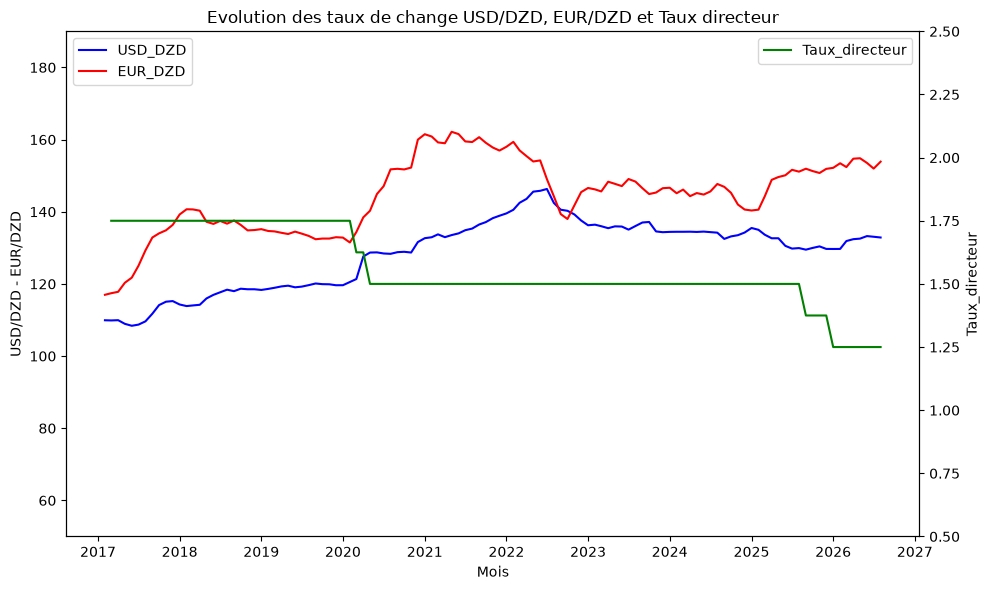

In [81]:



fig, ax1 = plt.subplots(figsize=(10, 6))
data_graph1 = data[data['Mois'] >= '2017-02-01']  
# First Y-axis
ax1.plot(data_graph1['Mois'], data_graph1['USD_DZD'],
         label='USD_DZD', color='blue')

ax1.plot(data_graph1['Mois'], data_graph1['EUR_DZD'],
         label='EUR_DZD', color='red')

ax1.set_ylim(50, 190)
ax1.set_xlabel('Mois')
ax1.set_ylabel('USD/DZD - EUR/DZD')
ax1.legend(loc='upper left')


# Second Y-axis
ax2 = ax1.twinx()

ax2.plot(data_graph1['Mois'], data_graph1['Taux_directeur']*50,
         label='Taux_directeur', color='green')

ax2.set_ylim(0.5, 2.5)
ax2.set_ylabel('Taux_directeur')
ax2.legend(loc='upper right')

plt.title('Evolution des taux de change USD/DZD, EUR/DZD et Taux directeur')
plt.tight_layout()
plt.show()

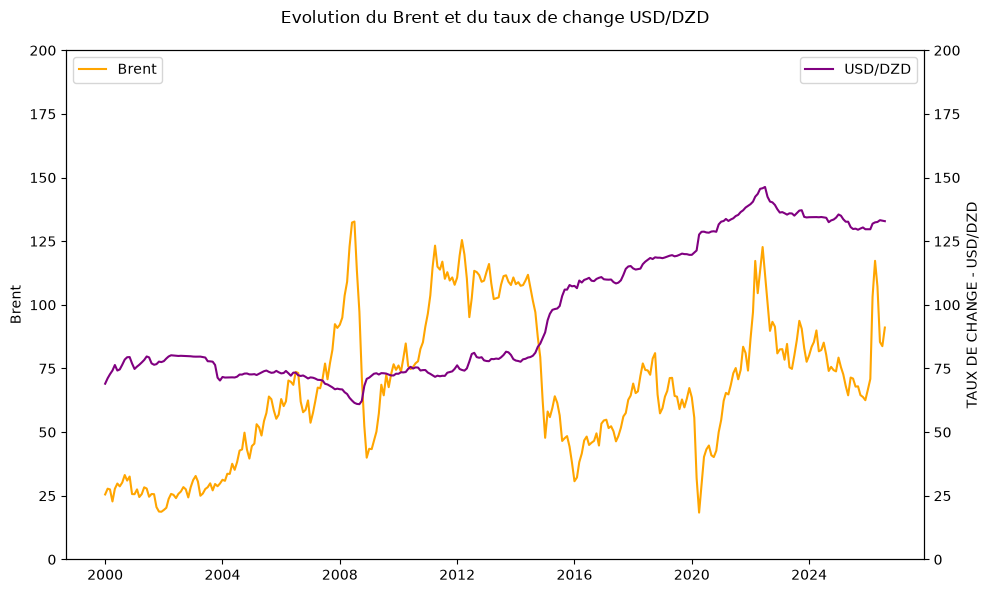

In [84]:
data_graph2 = data

fig, ax1 = plt.subplots(figsize=(10, 6))


ax1.plot(data_graph2['Mois'], data_graph2['Brent'], label='Brent', color='orange')
ax1.set_ylabel('Brent')
ax1.legend(loc='upper left')
ax1.set_ylim(0, 200)

ax2 = ax1.twinx()
ax2.plot(data_graph2['Mois'], data_graph2['USD_DZD'], label='USD/DZD', color='purple')
ax2.set_ylabel('TAUX DE CHANGE - USD/DZD')
ax2.legend(loc='upper right')
ax2.set_ylim(0, 200)
fig.suptitle('Evolution du Brent et du taux de change USD/DZD')
plt.tight_layout()

In [ ]:
df = df.loc['2017-01':'2023-12'].copy()

df['Taux_directeur_BA'] = df['Taux_directeur_BA'].ffill()

df = df.dropna()

variations = df[['USD_DZD', 'EUR_DZD', 'Brent', 'RSV']].pct_change()

variations['Taux_directeur_BA'] = df['Taux_directeur_BA'].diff()

variations['diff_infl'] = df['diff_infl'].diff()

variations = variations.dropna()

print(variations.shape)
print(variations.describe().round(4))



(71, 6)
       USD_DZD  EUR_DZD    Brent      RSV  Taux_directeur_BA  diff_infl
count  71.0000  71.0000  71.0000  71.0000            71.0000    71.0000
mean    0.0023   0.0008   0.0111  -0.0045            -0.0001     0.0004
std     0.0094   0.0147   0.1370   0.0206             0.0004     0.0088
min    -0.0264  -0.0343  -0.4258  -0.0281            -0.0025    -0.0185
25%    -0.0016  -0.0062  -0.0566  -0.0218             0.0000    -0.0063
50%     0.0020  -0.0012   0.0195  -0.0097             0.0000    -0.0001
75%     0.0061   0.0073   0.0746   0.0071             0.0000     0.0075
max     0.0515   0.0509   0.5985   0.0520             0.0000     0.0202


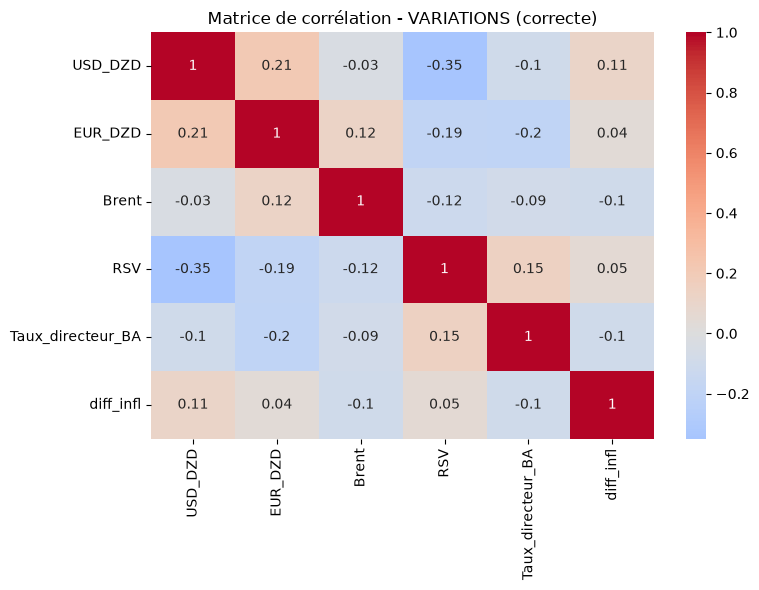

In [113]:

corr_des_variations = variations.corr().round(2)

plt.figure(figsize=(8,6))
sns.heatmap(corr_des_variations, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation - VARIATIONS (correcte)')
plt.tight_layout()
plt.show()